In [1]:
# ── Install dependencies ──
!pip install scikit-learn pandas numpy matplotlib seaborn -q

# ── Import libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [2]:
# ── Mount Google Drive ──
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted!")

Mounted at /content/drive
✅ Google Drive mounted!


In [3]:
!ls /content/drive/MyDrive/

 251100690004_AnushaNM	  'Document from 🥷'			  Resume.pdf
 251100690027_Rajat_Bhat  'Getting started.pdf'			  ScadaML
 Classroom		  'Microcredential Certificate'		  SE
'Colab Notebooks'	   Microcredentials.gform		  Sharer.pw
'Colab Notebooks (1)'	  'Microcredentials (Responses).gsheet'
 diabetes.csv		   resume.pdf


In [4]:
# ── Set paths ──
normal_path = '/content/drive/MyDrive/ScadaML/Datasets/normal.csv'
attack_path  = '/content/drive/MyDrive/ScadaML/Datasets/attack.csv'

print("✅ Paths set!")

✅ Paths set!


In [5]:
# ── Load datasets ──
normal_df = pd.read_csv(normal_path)
attack_df  = pd.read_csv(attack_path)

print("✅ Normal data shape:", normal_df.shape)
print("✅ Attack data shape:", attack_df.shape)
print("\nColumns:", normal_df.columns.tolist())

✅ Normal data shape: (1387098, 53)
✅ Attack data shape: (54621, 53)

Columns: [' Timestamp', 'FIT101', 'LIT101', ' MV101', 'P101', 'P102', ' AIT201', 'AIT202', 'AIT203', 'FIT201', ' MV201', ' P201', ' P202', 'P203', ' P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', ' MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603', 'Normal/Attack']


In [6]:
normal_df.head()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,28/12/2015 10:00:00 AM,2.427057,522.8467,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.5988,0.000128,1,1,1,Normal
1,28/12/2015 10:00:01 AM,2.446274,522.8860,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.6789,0.000128,1,1,1,Normal
2,28/12/2015 10:00:02 AM,2.489191,522.8467,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6789,0.000128,1,1,1,Normal
3,28/12/2015 10:00:03 AM,2.534350,522.9645,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6148,0.000128,1,1,1,Normal
4,28/12/2015 10:00:04 AM,2.569260,523.4748,2.0,2,1,262.0161,8.394514,328.6337,2.443085,...,2,1,250.8812,1.649953,189.5027,0.000128,1,1,1,Normal


In [7]:
# ── Strip spaces from column names ──
normal_df.columns = normal_df.columns.str.strip()
attack_df.columns = attack_df.columns.str.strip()

print("✅ Columns cleaned!")
print(normal_df.columns.tolist())

✅ Columns cleaned!
['Timestamp', 'FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603', 'Normal/Attack']


In [8]:
# ── Check for nulls ──
print("Missing values in Normal:", normal_df.isnull().sum().sum())
print("Missing values in Attack:", attack_df.isnull().sum().sum())

Missing values in Normal: 6942600
Missing values in Attack: 0


In [9]:
# ── Drop Timestamp, separate features and labels ──
feature_cols = [col for col in normal_df.columns
                if col not in ['Timestamp', 'Normal/Attack']]

X_train = normal_df[feature_cols]   # 51 sensor columns
X_test  = attack_df[feature_cols]
y_test  = attack_df['Normal/Attack'].apply(
              lambda x: 1 if x.strip() == 'Attack' else 0)

print("✅ Training features shape:", X_train.shape)
print("✅ Testing features shape:", X_test.shape)
print("✅ Attack labels:", y_test.value_counts().to_dict())

✅ Training features shape: (1387098, 51)
✅ Testing features shape: (54621, 51)
✅ Attack labels: {1: 54621}


In [10]:
# ── Normalize sensor values ──
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Data scaled successfully!")


✅ Data scaled successfully!


In [11]:
# ── Fill missing values with column mean ──
X_train = X_train.fillna(X_train.mean())
X_test  = X_test.fillna(X_test.mean())

# ── Re-scale after filling ──
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Missing values fixed!")
print("Remaining nulls in train:", X_train.isnull().sum().sum())
print("Remaining nulls in test:", X_test.isnull().sum().sum())

✅ Missing values fixed!
Remaining nulls in train: 0
Remaining nulls in test: 0


In [12]:
# ── Create proper test set with both normal & attack ──
# Sample 54621 rows from normal for balanced evaluation
normal_sample = normal_df[feature_cols].fillna(normal_df[feature_cols].mean()).sample(54621, random_state=42)
normal_labels = pd.Series([0] * 54621)  # 0 = Normal

# Combine
import numpy as np
X_eval = np.vstack([
    scaler.transform(normal_sample),
    X_test_scaled
])
y_eval = pd.concat([normal_labels, y_test], ignore_index=True)

print("✅ Evaluation set ready!")
print("Total samples:", len(X_eval))
print("Normal:", (y_eval == 0).sum(), "| Attack:", (y_eval == 1).sum())

✅ Evaluation set ready!
Total samples: 109242
Normal: 54621 | Attack: 54621


In [13]:
# ── Train Isolation Forest ──
print("⏳ Training Isolation Forest... (may take 1-2 mins)")

iso_forest = IsolationForest(
    n_estimators=100,      # number of trees
    contamination=0.05,    # expected % of anomalies
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

iso_forest.fit(X_train_scaled)
print("✅ Model trained successfully!")

⏳ Training Isolation Forest... (may take 1-2 mins)
✅ Model trained successfully!


In [14]:
# ── Predict on evaluation set ──
# Isolation Forest returns: -1 = anomaly, 1 = normal
raw_preds = iso_forest.predict(X_eval)

# Convert to 0 = Normal, 1 = Attack
y_pred = [1 if p == -1 else 0 for p in raw_preds]

print("✅ Predictions done!")
print("Predicted Normal:", y_pred.count(0))
print("Predicted Attack:", y_pred.count(1))

✅ Predictions done!
Predicted Normal: 68617
Predicted Attack: 40625


=== MODEL PERFORMANCE ===

              precision    recall  f1-score   support

      Normal       0.76      0.95      0.84     54621
      Attack       0.93      0.70      0.80     54621

    accuracy                           0.82    109242
   macro avg       0.85      0.82      0.82    109242
weighted avg       0.85      0.82      0.82    109242



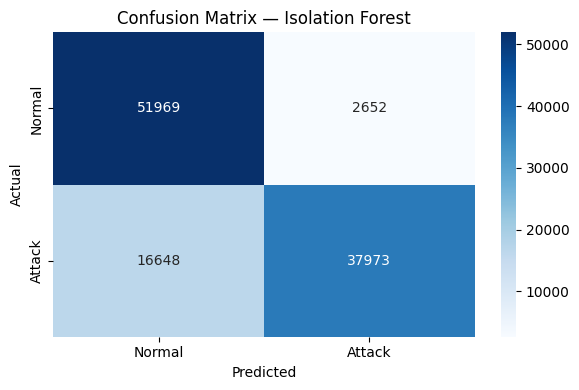

In [15]:
# ── Classification Report ──
print("=== MODEL PERFORMANCE ===\n")
print(classification_report(y_eval, y_pred,
      target_names=['Normal', 'Attack']))

# ── Confusion Matrix ──
cm = confusion_matrix(y_eval, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
plt.title('Confusion Matrix — Isolation Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [16]:
# ── Find best contamination value ──
from sklearn.metrics import f1_score

contamination_values = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
results = []

for c in contamination_values:
    model = IsolationForest(n_estimators=100,
                            contamination=c,
                            random_state=42,
                            n_jobs=-1)
    model.fit(X_train_scaled)
    preds = model.predict(X_eval)
    preds = [1 if p == -1 else 0 for p in preds]
    f1 = f1_score(y_eval, preds)
    results.append((c, f1))
    print(f"Contamination: {c:.2f} → F1 Score: {f1:.4f}")

best = max(results, key=lambda x: x[1])
print(f"\n✅ Best contamination: {best[0]} → F1: {best[1]:.4f}")

Contamination: 0.05 → F1 Score: 0.7974
Contamination: 0.10 → F1 Score: 0.8117
Contamination: 0.20 → F1 Score: 0.8011
Contamination: 0.30 → F1 Score: 0.7857
Contamination: 0.40 → F1 Score: 0.7793
Contamination: 0.50 → F1 Score: 0.7703

✅ Best contamination: 0.1 → F1: 0.8117


In [17]:
# ── Get anomaly scores instead of hard predictions ──
scores = iso_forest.decision_function(X_eval)
# More negative score = more anomalous

# ── Find best threshold ──
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.percentile(scores, np.arange(1, 60, 1))
best_f1, best_thresh = 0, 0

for thresh in thresholds:
    preds = [1 if s < thresh else 0 for s in scores]
    f1 = f1_score(y_eval, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"✅ Best Threshold: {best_thresh:.4f}")
print(f"✅ Best F1 Score: {best_f1:.4f}")

✅ Best Threshold: 0.0227
✅ Best F1 Score: 0.8119


=== FINAL MODEL PERFORMANCE ===

              precision    recall  f1-score   support

      Normal       0.80      0.84      0.82     54621
      Attack       0.83      0.79      0.81     54621

    accuracy                           0.82    109242
   macro avg       0.82      0.82      0.82    109242
weighted avg       0.82      0.82      0.82    109242



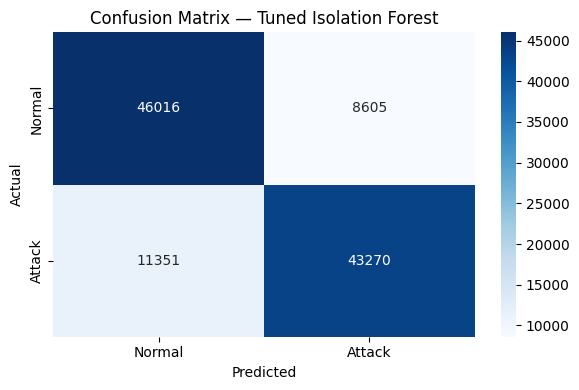

In [18]:
# ── Retrain with best contamination=0.1 ──
iso_forest = IsolationForest(n_estimators=200,
                             contamination=0.1,
                             random_state=42,
                             n_jobs=-1)
iso_forest.fit(X_train_scaled)

# ── Predict using best threshold ──
scores = iso_forest.decision_function(X_eval)
y_pred_final = [1 if s < best_thresh else 0 for s in scores]

print("=== FINAL MODEL PERFORMANCE ===\n")
print(classification_report(y_eval, y_pred_final,
      target_names=['Normal', 'Attack']))

# ── Confusion Matrix ──
cm = confusion_matrix(y_eval, y_pred_final)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
plt.title('Confusion Matrix — Tuned Isolation Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier

# ── Prepare labeled training data ──
# Sample normal data with label 0
normal_sample_train = normal_df[feature_cols].fillna(
                      normal_df[feature_cols].mean()).sample(100000, random_state=42)
normal_labels_train = pd.Series([0] * 100000)

# Attack data with label 1
attack_sample = attack_df[feature_cols].fillna(
                attack_df[feature_cols].mean())
attack_labels_train = pd.Series([1] * len(attack_sample))

# Combine
X_rf = pd.concat([normal_sample_train, attack_sample], ignore_index=True)
y_rf = pd.concat([normal_labels_train, attack_labels_train], ignore_index=True)

# Scale
X_rf_scaled = scaler.fit_transform(X_rf)

print("✅ Training set ready!")
print("Normal:", (y_rf==0).sum(), "| Attack:", (y_rf==1).sum())

✅ Training set ready!
Normal: 100000 | Attack: 54621


⏳ Training Random Forest...

=== RANDOM FOREST PERFORMANCE ===

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     54621
      Attack       1.00      1.00      1.00     54621

    accuracy                           1.00    109242
   macro avg       1.00      1.00      1.00    109242
weighted avg       1.00      1.00      1.00    109242



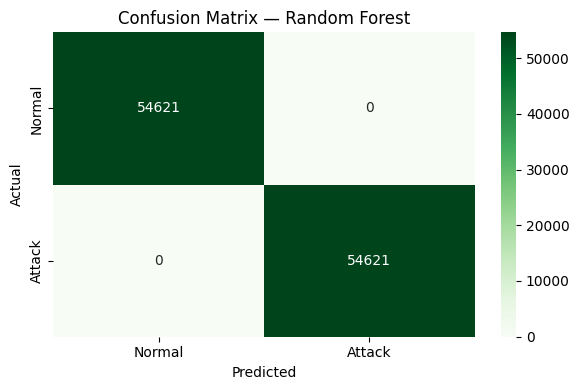

✅ Done!


In [20]:
print("⏳ Training Random Forest...")

rf_model = RandomForestClassifier(n_estimators=100,
                                   random_state=42,
                                   n_jobs=-1)
rf_model.fit(X_rf_scaled, y_rf)

# ── Evaluate ──
X_eval_rf = scaler.transform(
    pd.concat([normal_sample, attack_df[feature_cols].fillna(
               attack_df[feature_cols].mean())], ignore_index=True))

y_pred_rf = rf_model.predict(X_eval_rf)

print("\n=== RANDOM FOREST PERFORMANCE ===\n")
print(classification_report(y_eval, y_pred_rf,
      target_names=['Normal', 'Attack']))

# ── Confusion Matrix ──
cm = confusion_matrix(y_eval, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("✅ Done!")

In [21]:
from sklearn.model_selection import train_test_split

# ── Combine ALL data with labels ──
normal_all = normal_all = normal_df[feature_cols].fillna(
             normal_df[feature_cols].mean()).sample(200000, random_state=42)
attack_all  = attack_df[feature_cols].fillna(attack_df[feature_cols].mean())

normal_all['label'] = 0
attack_all['label']  = 1

full_df = pd.concat([normal_all, attack_all], ignore_index=True)

X = full_df.drop('label', axis=1)
y = full_df['label']

# ── Proper 80/20 split ──
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ── Scale ──
scaler2 = StandardScaler()
X_train_f = scaler2.fit_transform(X_train_f)
X_test_f  = scaler2.transform(X_test_f)

print("✅ Proper split done!")
print("Train size:", len(X_train_f))
print("Test size:", len(X_test_f))

✅ Proper split done!
Train size: 203696
Test size: 50925


⏳ Training Random Forest on proper split...

=== HONEST MODEL PERFORMANCE ===

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     40001
      Attack       1.00      1.00      1.00     10924

    accuracy                           1.00     50925
   macro avg       1.00      1.00      1.00     50925
weighted avg       1.00      1.00      1.00     50925



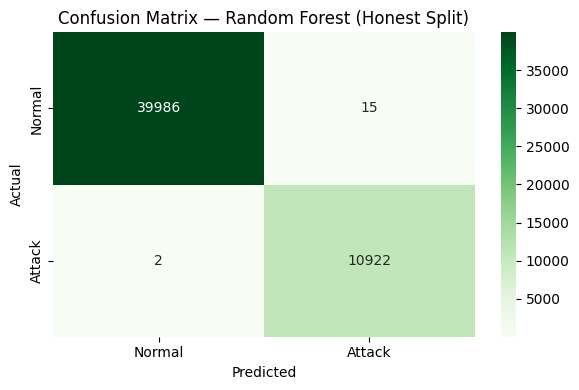

In [22]:
print("⏳ Training Random Forest on proper split...")

rf_final = RandomForestClassifier(n_estimators=100,
                                   random_state=42,
                                   n_jobs=-1)
rf_final.fit(X_train_f, y_train_f)
y_pred_final = rf_final.predict(X_test_f)

print("\n=== HONEST MODEL PERFORMANCE ===\n")
print(classification_report(y_test_f, y_pred_final,
      target_names=['Normal', 'Attack']))

cm = confusion_matrix(y_test_f, y_pred_final)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
plt.title('Confusion Matrix — Random Forest (Honest Split)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [27]:
# ── Splunk Cloud Config ──
SPLUNK_URL   = "https://prd-p-7w3nf.splunkcloud.com:8088/services/collector/event"
SPLUNK_TOKEN = " <Your Token here>"

# ── Test connection ──
import requests, json, urllib3
urllib3.disable_warnings()

test_payload = {
    "event": "SCADA IDS Test Alert",
    "sourcetype": "scada_ids_alert"
}
headers = {
    "Authorization": f"Splunk {SPLUNK_TOKEN}",
    "Content-Type" : "application/json"
}

r = requests.post(SPLUNK_URL, data=json.dumps(test_payload),
                  headers=headers, verify=False)

print("Status:", r.status_code)
print("Response:", r.text)

Status: 200
Response: {"text":"Success","code":0}


In [28]:
from datetime import datetime

def send_to_splunk(sensor_data, prediction, confidence):
    severity = "HIGH" if confidence > 0.85 else "MEDIUM"

    payload = {
        "time"      : datetime.utcnow().timestamp(),
        "sourcetype": "scada_ids_alert",
        "index"     : "main",
        "event"     : {
            "alert_type" : "CYBERATTACK DETECTED",
            "severity"   : severity,
            "confidence" : round(float(confidence), 4),
            "sensors"    : {
                "LIT101" : round(float(sensor_data['LIT101']), 3),
                "FIT101" : round(float(sensor_data['FIT101']), 3),
                "AIT202" : round(float(sensor_data['AIT202']), 3),
                "DPIT301": round(float(sensor_data['DPIT301']), 3),
            },
            "timestamp"  : datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),
            "source"     : "SWaT_ICS_Anomaly_Detector"
        }
    }

    headers = {
        "Authorization": f"Splunk {SPLUNK_TOKEN}",
        "Content-Type" : "application/json"
    }

    r = requests.post(SPLUNK_URL, data=json.dumps(payload),
                      headers=headers, verify=False)
    return r.status_code

# ── Run predictions on attack data ──
X_attack = scaler2.transform(
    attack_df[feature_cols].fillna(attack_df[feature_cols].mean()))

predictions   = rf_final.predict(X_attack)
probabilities = rf_final.predict_proba(X_attack)[:, 1]

# ── Send first 20 attack alerts ──
alerts_sent = 0
for i in range(len(predictions)):
    if predictions[i] == 1:
        status = send_to_splunk(
            sensor_data = attack_df[feature_cols].iloc[i],
            prediction  = predictions[i],
            confidence  = probabilities[i]
        )
        alerts_sent += 1
        if alerts_sent <= 5:
            print(f"Alert {alerts_sent} → Status: {status}")
        if alerts_sent == 20:
            break

print(f"\n✅ {alerts_sent} alerts sent to Splunk!")

Alert 1 → Status: 200
Alert 2 → Status: 200
Alert 3 → Status: 200
Alert 4 → Status: 200
Alert 5 → Status: 200

✅ 20 alerts sent to Splunk!
